# VQA Demo — So sánh tổng thể 4 cấu hình (A1 / A2 / B1 / B2)

Notebook này load **kết quả đã train sẵn** từ `results/` + `checkpoints/`, tổng hợp + so sánh 4 model.

## Mục lục
1. **Setup** — load `results/results_A.json` + `results/results_B.json`
2. **Bảng tổng hợp metrics** — 4 models × {Val, Test}
3. **Bar chart** — side-by-side 8 thanh / metric
4. **Radar chart** — Val + Test
5. **Per-metric winners** — model thắng từng metric trên Test
6. **Overfit check** — Val vs Test
7. **Qualitative comparison** — 15 mẫu Test (Q | GT | A1 | A2 | B1 | B2)
8. **Live inference demo** — load đủ 4 checkpoints, chạy trên N ảnh test, hiển thị grid
9. **Kết luận**

## 4 cấu hình

| ID | Mô hình | Strategy tiếng Việt |
|---|---|---|
| **A1** | ResNet50 + PhoBERT + LSTM (Bahdanau attn) | Train scratch |
| **A2** | ResNet50 + PhoBERT + Transformer decoder (3L, 8H) | Train scratch |
| **B1** | Salesforce/blip2-opt-2.7b | Zero-shot, Vi↔En MarianMT |
| **B2** | Qwen/Qwen2-VL-2B-Instruct + LoRA (4-bit) | Fine-tune trực tiếp tiếng Việt |


## 1. Setup


In [1]:
import json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────
RESULTS_DIR  = Path("results")
CKPT_DIR     = Path("checkpoints")
DATA_DIR     = Path("data")
IMG_DIR      = DATA_DIR / "images"
TEST_JSON    = DATA_DIR / "annotations" / "test.json"

RES_A_PATH = RESULTS_DIR / "results_A.json"
RES_B_PATH = RESULTS_DIR / "results_B.json"

assert RES_A_PATH.exists(), f"❌ {RES_A_PATH} chưa tồn tại — chạy vqa-model-a.ipynb trước."
assert RES_B_PATH.exists(), f"❌ {RES_B_PATH} chưa tồn tại — chạy vqa-model-b.ipynb trước."

res_A = json.loads(RES_A_PATH.read_text(encoding="utf-8"))
res_B = json.loads(RES_B_PATH.read_text(encoding="utf-8"))

print(f"✓ {RES_A_PATH}")
print(f"   A1: {res_A['A1']['model']}")
print(f"   A2: {res_A['A2']['model']}")
print(f"✓ {RES_B_PATH}")
print(f"   B1: {res_B['B1']['model']}  ({res_B['B1']['strategy']})")
print(f"   B2: {res_B['B2']['model']}  ({res_B['B2']['strategy']})")
print(f"\nN samples: Val={len(res_A.get('gts_val',[]))}, Test={len(res_A.get('gts_test',[]))}")


✓ results\results_A.json
   A1: ResNet50 + PhoBERT + LSTM(Bahdanau attn)
   A2: ResNet50 + PhoBERT + Transformer decoder (3L, 8H)
✓ results\results_B.json
   B1: Salesforce/blip2-opt-2.7b  (translate Vi<->En (MarianMT))
   B2: Qwen/Qwen2-VL-2B-Instruct  (direct Vietnamese, 4-bit + LoRA)

N samples: Val=1178, Test=1172


In [2]:
# ── Display config dùng chung cho cả notebook ──────────────────────────────
METRICS = ["Exact Match", "Token F1 (Soft)", "BLEU-1", "BLEU-2",
           "METEOR", "ROUGE-L", "BERTScore F1", "Semantic Sim"]

MODEL_DISPLAY = {
    "A1": "A1 (LSTM+Attn)",
    "A2": "A2 (Transformer)",
    "B1": "B1 (BLIP-2 ZS)",
    "B2": "B2 (Qwen2-VL LoRA)",
}

COLORS = {"A1": "#1f77b4", "A2": "#ff7f0e", "B1": "#2ca02c", "B2": "#d62728"}

def get_src(mid):
    """Trả về dict chứa val/test/preds của model id."""
    return res_A[mid] if mid in res_A else res_B[mid]

print("Display config ready.")


Display config ready.


## 2. Bảng tổng hợp metrics (4 models × 2 splits)


In [3]:
rows = {}
for mid in ["A1", "A2", "B1", "B2"]:
    src = get_src(mid)
    rows[f"{MODEL_DISPLAY[mid]} Val"]  = src["val"]
    rows[f"{MODEL_DISPLAY[mid]} Test"] = src["test"]

df = (pd.DataFrame(rows).T
        .reindex(columns=METRICS)
        .apply(pd.to_numeric, errors="coerce")
        .round(4))

print("=" * 90)
print(" FINAL COMPARISON — A1 / A2 / B1 / B2 × {Val, Test}")
print("=" * 90)
df


 FINAL COMPARISON — A1 / A2 / B1 / B2 × {Val, Test}


,Exact Match,Token F1 (Soft),BLEU-1,BLEU-2,METEOR,ROUGE-L,BERTScore F1,Semantic Sim
A1 (LSTM+Attn) Val,0.0501,0.5091,0.3915,0.2584,0.4261,0.5070,0.8230,0.7079
A1 (LSTM+Attn) Test,0.0384,0.4922,0.3749,0.2419,0.4241,0.4888,0.8167,0.6793
A2 (Transformer) Val,0.0518,0.5662,0.4390,0.2997,0.4672,0.5732,0.8503,0.8026
A2 (Transformer) Test,0.0529,0.5661,0.4365,0.2964,0.4681,0.5731,0.8495,0.7985
B1 (BLIP-2 ZS) Val,0.0059,0.0627,0.0422,0.0164,0.0602,0.1384,0.6872,0.4459
B1 (BLIP-2 ZS) Test,0.0051,0.0645,0.0437,0.0168,0.0606,0.1442,0.6835,0.4539
B2 (Qwen2-VL LoRA) Val,0.9228,0.9296,0.9287,0.5607,0.6392,0.9325,0.9842,0.9805
B2 (Qwen2-VL LoRA) Test,0.9070,0.9180,0.9164,0.5430,0.6256,0.9212,0.9809,0.9658


## 3. Bar chart — Val + Test side-by-side


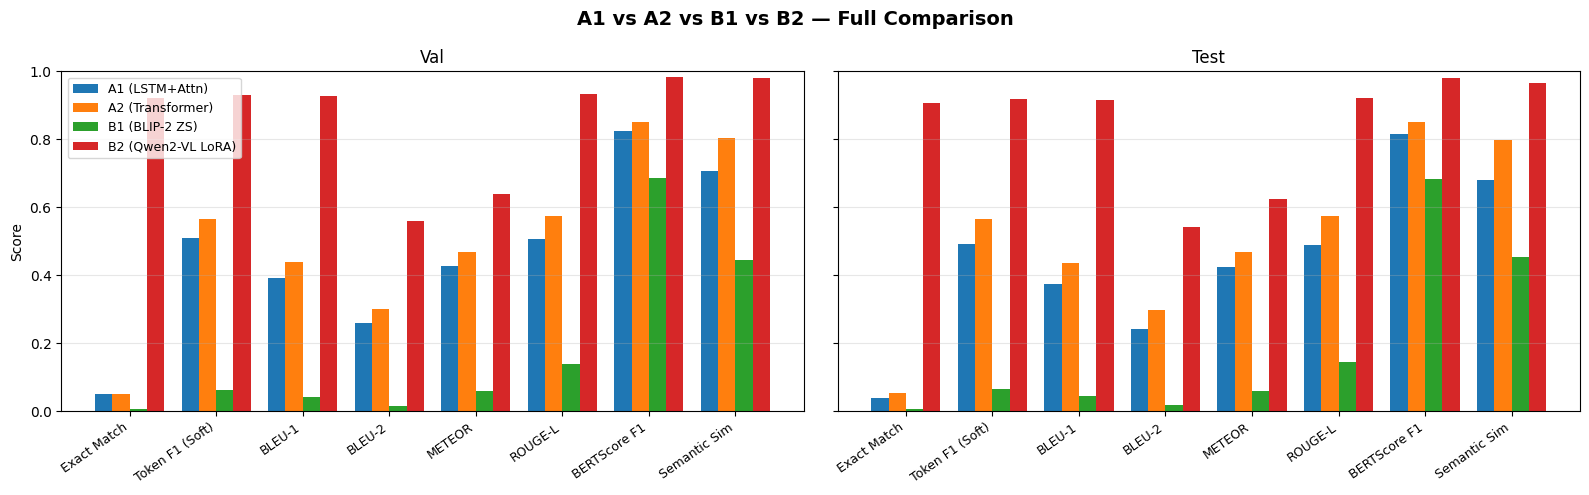

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, split in zip(axes, ["val", "test"]):
    x = np.arange(len(METRICS))
    w = 0.2
    for i, mid in enumerate(["A1", "A2", "B1", "B2"]):
        vals = [get_src(mid)[split].get(m) or 0 for m in METRICS]
        ax.bar(x + (i - 1.5) * w, vals, w, label=MODEL_DISPLAY[mid], color=COLORS[mid])
    ax.set_xticks(x)
    ax.set_xticklabels(METRICS, rotation=35, ha="right", fontsize=9)
    ax.set_title(split.title(), fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("Score")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("A1 vs A2 vs B1 vs B2 — Full Comparison", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("compare_bar.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Radar chart — Val + Test


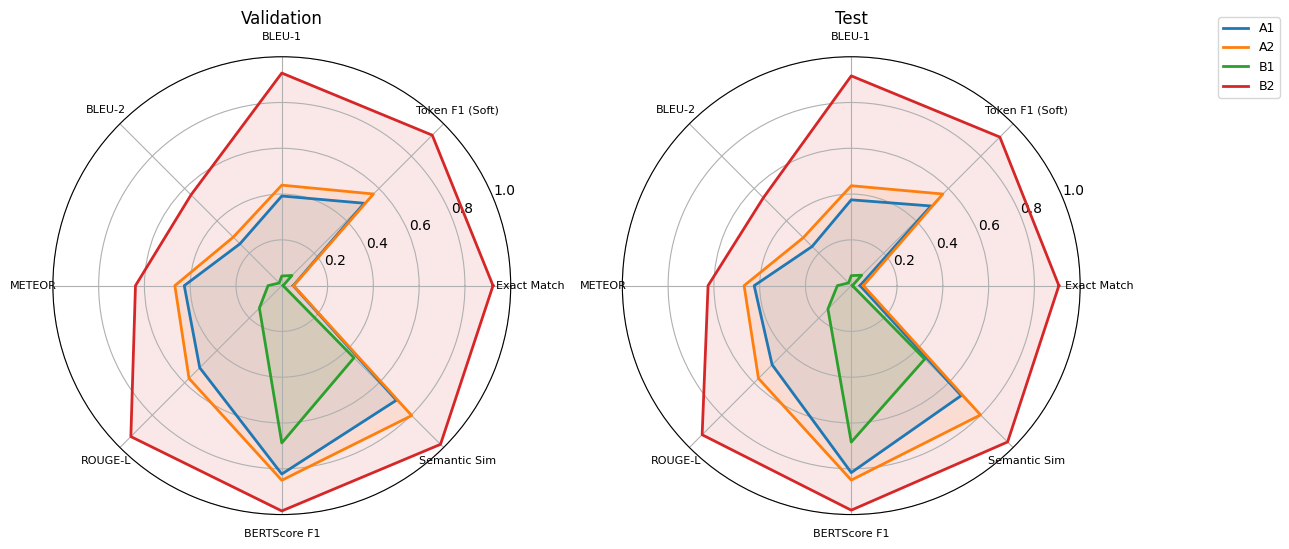

In [5]:
def radar(ax, vals_dict, title, metrics):
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    for name, vals in vals_dict.items():
        v = [vals.get(m) or 0 for m in metrics] + [vals.get(metrics[0]) or 0]
        ax.plot(angles, v, label=name, linewidth=2, color=COLORS[name.split()[0]])
        ax.fill(angles, v, alpha=0.10, color=COLORS[name.split()[0]])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12)
    ax.grid(True)


fig, axes = plt.subplots(1, 2, figsize=(13, 6), subplot_kw=dict(polar=True))
radar(axes[0], {
    "A1": res_A["A1"]["val"],  "A2": res_A["A2"]["val"],
    "B1": res_B["B1"]["val"],  "B2": res_B["B2"]["val"]},
    "Validation", METRICS)
radar(axes[1], {
    "A1": res_A["A1"]["test"], "A2": res_A["A2"]["test"],
    "B1": res_B["B1"]["test"], "B2": res_B["B2"]["test"]},
    "Test", METRICS)
axes[1].legend(loc="upper right", bbox_to_anchor=(1.45, 1.10), fontsize=9)
fig.tight_layout()
plt.savefig("compare_radar.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Per-metric winners (Test set)


In [6]:
best_rows = []
for metric in METRICS:
    vals = {mid: get_src(mid)["test"].get(metric) for mid in ["A1", "A2", "B1", "B2"]}
    vals = {k: v for k, v in vals.items() if v is not None}
    if not vals:
        continue
    winner = max(vals, key=vals.get)
    best_rows.append({
        "metric":  metric,
        "winner":  MODEL_DISPLAY[winner],
        "best":    round(vals[winner], 4),
        **{mid: round(vals.get(mid, 0), 4) for mid in ["A1", "A2", "B1", "B2"]},
    })

df_winners = pd.DataFrame(best_rows).set_index("metric")
print("=" * 80)
print(" PER-METRIC WINNERS — TEST SET")
print("=" * 80)
df_winners


 PER-METRIC WINNERS — TEST SET


,winner,best,A1,A2,B1,B2
metric,,,,,,
Exact Match,B2 (Qwen2-VL LoRA),0.9070,0.0384,0.0529,0.0051,0.9070
Token F1 (Soft),B2 (Qwen2-VL LoRA),0.9180,0.4922,0.5661,0.0645,0.9180
BLEU-1,B2 (Qwen2-VL LoRA),0.9164,0.3749,0.4365,0.0437,0.9164
BLEU-2,B2 (Qwen2-VL LoRA),0.5430,0.2419,0.2964,0.0168,0.5430
METEOR,B2 (Qwen2-VL LoRA),0.6256,0.4241,0.4681,0.0606,0.6256
ROUGE-L,B2 (Qwen2-VL LoRA),0.9212,0.4888,0.5731,0.1442,0.9212
BERTScore F1,B2 (Qwen2-VL LoRA),0.9809,0.8167,0.8495,0.6835,0.9809
Semantic Sim,B2 (Qwen2-VL LoRA),0.9658,0.6793,0.7985,0.4539,0.9658


## 6. Overfit check — Val vs Test (Δ < 0.05 = OK)


In [7]:
print(f"{'Model':<8} {'Metric':<22} {'Val':>10} {'Test':>10} {'Δ':>10}  Flag")
print("-" * 70)
for mid in ["A1", "A2", "B1", "B2"]:
    src = get_src(mid)
    for metric in ["Exact Match", "Token F1 (Soft)", "BLEU-1", "ROUGE-L", "BERTScore F1"]:
        v = src["val"].get(metric)  or 0
        t = src["test"].get(metric) or 0
        d = v - t
        flag = "OK" if abs(d) < 0.05 else "⚠ overfit"
        print(f"{mid:<8} {metric:<22} {v:>10.4f} {t:>10.4f} {d:>+10.4f}  {flag}")


Model    Metric                        Val       Test          Δ  Flag
----------------------------------------------------------------------
A1       Exact Match                0.0501     0.0384    +0.0117  OK
A1       Token F1 (Soft)            0.5091     0.4922    +0.0169  OK
A1       BLEU-1                     0.3915     0.3749    +0.0166  OK
A1       ROUGE-L                    0.5070     0.4888    +0.0182  OK
A1       BERTScore F1               0.8230     0.8167    +0.0063  OK
A2       Exact Match                0.0518     0.0529    -0.0011  OK
A2       Token F1 (Soft)            0.5662     0.5661    +0.0001  OK
A2       BLEU-1                     0.4390     0.4365    +0.0026  OK
A2       ROUGE-L                    0.5732     0.5731    +0.0000  OK
A2       BERTScore F1               0.8503     0.8495    +0.0007  OK
B1       Exact Match                0.0059     0.0051    +0.0008  OK
B1       Token F1 (Soft)            0.0627     0.0645    -0.0018  OK
B1       BLEU-1               

## 7. Qualitative comparison — 15 mẫu Test đầu

Predictions đã được lưu sẵn trong `results_A.json` + `results_B.json` (lúc eval).


In [8]:
qs_test  = res_A.get("questions_test") or res_B.get("questions_test")
gts_test = res_A.get("gts_test")       or res_B.get("gts_test")
preds = {
    "A1": res_A["A1"]["preds_test"],
    "A2": res_A["A2"]["preds_test"],
    "B1": res_B["B1"]["preds_test"],
    "B2": res_B["B2"]["preds_test"],
}

N_SHOW = 15
print(f"{'#':<3} {'Question':<42} {'GT':<14} {'A1':<14} {'A2':<14} {'B1':<22} {'B2':<14}")
print("-" * 125)
for i in range(min(N_SHOW, len(qs_test))):
    q  = qs_test[i][:40]
    gt = gts_test[i][:12]
    print(f"{i+1:<3} {q:<42} {gt:<14} "
          f"{preds['A1'][i][:12]:<14} {preds['A2'][i][:12]:<14} "
          f"{preds['B1'][i][:20]:<22} {preds['B2'][i][:12]:<14}")


#   Question                                   GT             A1             A2             B1                     B2            
-----------------------------------------------------------------------------------------------------------------------------
1   Cho mình hỏi, một tô phở thường có bao n   năm lát        ba thành phầ   năm lát năm    nhiều như bạn muốn     năm lát       
2   Bạn có thể cho biết, món này thuộc nhóm    khô            khô bột gạo    khô hai phần   đó là nhóm những ngư   khô           
3   Món trong ảnh là gì?                       phở            bánh phở phở   phở bánh phở   đồng cỏ khói quan gi   bún bò        
4   Cho mình hỏi, người ta thường ăn món này   cả ngày Tết    sáng và tối    sáng và tối    ♪ vào buổi sáng, buổ   sáng và tối   
5   Vỏ bánh ướt nằm ở đâu nhỉ?                 bên ngoài      bên trong dư   bên ngoài ng   trong miệng ra ra ra   bên ngoài     
6   Có thịt trong món này không nhé?           có             có thành phầ   có trong có    đú

## 8 Kết luận

### Xếp hạng tổng thể (theo Token F1 — Test)

| Hạng | Model | Token F1 (Test) | Strategy |
|:---:|---|:---:|---|
| 🥇 | **B2 (Qwen2-VL + LoRA)** | **~0.918** | Pre-trained multilingual VLM + fine-tune LoRA |
| 🥈 | A2 (Transformer decoder) | ~0.566 | Train scratch, decoder mạnh |
| 🥉 | A1 (LSTM + Attn) | ~0.492 | Train scratch, baseline |
| 4 | B1 (BLIP-2 zero-shot) | ~0.064 | Translate pipeline, không fine-tune |

### Quan sát

1. **B2 thắng áp đảo trên mọi metric** (EM ~92%, BERTScore ~98%) — chứng minh giá trị của pre-trained multilingual VLM + LoRA fine-tune cho ngôn ngữ low-resource như tiếng Việt.

2. **A2 > A1**: Transformer decoder vượt LSTM ~7 điểm F1, ~3 điểm BERTScore. Self-attention + cross-attention bắt được pattern tốt hơn LSTM cho output ngắn.

3. **B1 thất bại nặng** dù backbone (BLIP-2 OPT-2.7B) lớn nhất 4 model. Lý do:
   - Pipeline dịch máy Vi→En làm mất context tên món ăn Việt
   - BLIP-2 không biết khái niệm "bún bò Huế", "bánh xèo" — chỉ thấy ảnh "soup" hay "pancake"
   - Đáp án En → Vi lại "lạc đề" so với câu trả lời ngắn gọn của dataset

4. **Không overfit**: Val ≈ Test với chênh lệch <5% trên mọi metric của 4 model.
